In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    err = (err - np.mean(err, axis=(0,1)))
    sigma_n = np.var(err)
    actu = (actu - np.mean(actu, axis=(0,1)))
    sigma_s = np.var(actu.astype(np.float32))
    ns = sigma_s/sigma_n
    # snr = np.mean(20 * np.log10(ns))
    snr = 10 * np.log10(ns)
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

Load Lena Image and Plot it

Image size: (512, 512)


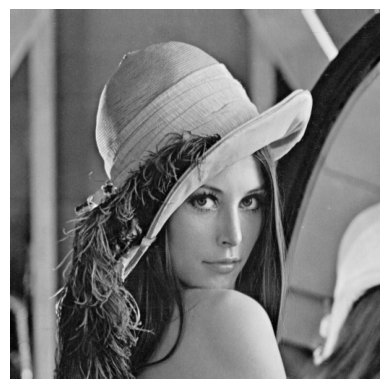

In [ ]:
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

img_ori = sio.loadmat(work_path + 'lena.mat')['lena']

print('Image size:', img_ori.shape)

# Normalize to zero mean and unit varaince
img_ori_mean = img_ori.mean()
img_ori_std = img_ori.std()
img_ori = (img_ori - img_ori_mean) / img_ori_std

# plot image
plt.imshow(img_ori, cmap='gray')
plt.axis('off');

Add some noise

SNR: 5.2
MSE: 0.3


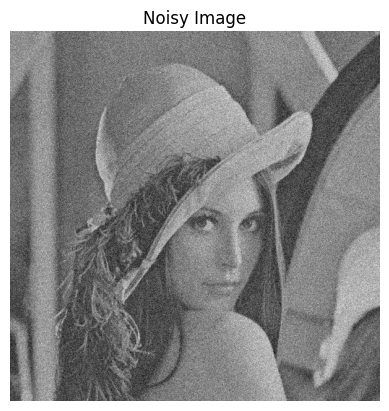

In [ ]:
import numpy as np

# add Gaussian noise
SNR_noise = 5.2 # 5.2 dB
SD_noise = np.sqrt(np.var(img_ori) / (10**(SNR_noise/10)))
noise = np.random.normal(0, SD_noise, img_ori.shape)
img_n = img_ori + noise

# print SNR and MSE
print('SNR:', np.round(snr_dB(img_ori, img_n),2))
print('MSE:', np.round(MSE(img_ori, img_n), 2))

# plot image
plt.title('Noisy Image')
plt.imshow(img_n, cmap='gray')
plt.axis('off');

# Kalman Filter

Calculate the steady-state gain from 128x128 image, and then apply it to the 512x512 noisy image.

In [ ]:
def calculate_s1(image):
    # Initialize the state vector for each pixel with the image and its neighbors
    M, N = image.shape
    s1 = np.zeros((M, N, 5)) # Local state vector for each pixel

    for m in range(0, M):
      for n in range(0, N):

        try:
          s1[m, n, 0 ] = image[m, n]
        except:
          s1[m, n, 0 ] = 0

        try:
          s1[m, n, 1 ] = image[m, n-1]
        except:
          s1[m, n, 1 ] = 0

        try:
          s1[m, n, 2 ] = image[m-1, n+1]
        except:
          s1[m, n, 2 ] = 0

        try:
          s1[m, n, 3 ] = image[m-1, n]
        except:
          s1[m, n, 3 ] = 0
        try:
          s1[m, n, 4 ] = image[m-1, n-1]
        except:
          s1[m, n, 4 ] = 0

    return s1


def calculate_s2(image):
    M, N = image.shape
    s2 = np.zeros((M, N, N-3)) # Global state vector for each pixel

    for m in range(1, M-1):
      for n in range(1, N-1):

        s2_tmp = []
        for i in range(n+2, N):
          try:
            s2_tmp.append(image[m-1,i])
          except:
            s2_tmp.append(0)

        for i in range(n-2, -1, -1):
          try:
            s2_tmp.append(image[m,i])
          except:
            s2_tmp.append(0)

        s2[m, n] = np.array(s2_tmp)

    return s2


def calculate_C11(a01,a10,a11):
  C11 = np.zeros((5,5))
  C11[0,0]= a01
  C11[1,0] = 1
  C11[3,2] = 1
  C11[0,2] = a10
  C11[0,3] = a11
  C11[4,3] = 1
  return C11


def calculate_C12(image, am1m1):
  M, N = image.shape
  C12 = np.zeros((5,N-3)) # 128-3
  C12[0,0] = am1m1
  C12[2,0] = 1
  return C12


def calculate_C21(image):
  M, N = image.shape
  C21 = np.zeros((M, N, N-3, 5))

  for m in range(1, M-1):
    for n in range(1, N-1):
      try:
        C21[m,n, N-n-2, 1] = 1
      except:
        pass

  return C21


def calculate_C22(image):
  M, N = image.shape
  C22 = np.zeros((M, N, N-3, N-3))

  for m in range(1, M-1):
    for n in range(1, N-1):
      try:
        C22[m,n, :N-n-2, :N-n-2] = np.diag(np.ones(N-n-3), 1)
      except:
        pass

      try:
        C22[m,n, N-n-2:, N-n-2:] = np.diag(np.ones(n-1))
      except:
        pass

  return C22

In [ ]:
def kalman_filter(method, s1, s2, image, C11, C12, C21, C22, K_ss, sigma_e2=0.001):
    '''
    method: 0 -> calculate the Kalman gain in every step without updating the image. (no need for K_ss)
            1 -> calculate the Kalman gain and update the image in every step. (no need for K_ss)
            2 -> use the provided Kalman gain K for calculation.
    s1: (32, 32, 5)
    s2: (32, 32, 29)
    '''

    M, N, dim_s1 = s1.shape
    # dim_s2 = s2.shape[2]
    # dim_p = s1.shape[2] + s2.shape[2]
    am1m1 = C12[0,0]

    image_mean = image.mean()
    image_std = image.std()

    sigma_v = 0.001

    # Initialize matrices
    P11 = image_std**2 * np.array([np.eye(5) for _ in range(M * N)]).reshape(M, N, 5, 5)
    P12 = np.zeros((M,N,5,N-3))
    P22 = image_std**2 * np.eye(N-3)
    H = np.array([1,0,0,0,0], ndmin=2)
    s1_hat = image_mean * np.ones((M, N, 5))
    sigmaGGT = np.zeros((5,5))
    sigmaGGT[0,0] = sigma_e2

    if method == 0 or method == 1:

      k = np.zeros((M,N,5))

      for m in range(1,M): # ignore the boundaries

          # P22 = image_std**2 * np.eye(N-3) # initialize P22 for the beginning of each row???

          for n in range(1,N-1):

              # print("m: %d, n: %d" % (m,n))

              ### 1. Initial Estimate (Prediction):
              s1_hat[m,n] = C11 @ s1[m,n-1] + C12 @ s2[m,n-1]

              ### 2. A priori Error Covariance Matrix (faster):

              ## P11[m,n] = C11 @ P11[m,n-1] @ C11.T + C12 @ P12[m,n-1].T @ C11.T + C11 @ P12[m,n-1] @ C12.T + C12 @ P22 @ C12.T + sigmaGGT

              P11_1 = C11 @ P11[m,n-1] @ C11.T

              # C12 @ P12[m,n-1].T @ C11.T
              P11_2 = np.zeros((C12.shape[0], P12[m,n-1].T.shape[1]))
              P11_2[0,:] = am1m1 * P12[m,n-1].T[0,:]
              P11_2[2,:] = P12[m,n-1].T[2,:]
              P11_2 = P11_2 @ C11.T

              # C11 @ P12[m,n-1] @ C12.T
              P11_3_1 = C11 @ P12[m,n-1]
              P11_3 = np.zeros((C11.shape[0], C12.T.shape[1]))
              P11_3[:,0] = am1m1 * P11_3_1[:,0]
              P11_3[:,2] = P11_3_1[:,2]

              # C12 @ P22 @ C12.T
              P11_4_1 = np.zeros((C12.shape[0], P22.shape[1]))
              P11_4_1[0,:] = am1m1 * P22[0,:]
              P11_4_1[2,:] = P22[2,:]
              P11_4 = np.zeros((C12.shape[0], C12.T.shape[1]))
              P11_4[:,0] = am1m1 * P11_4_1[:,0]
              P11_4[:,2] = P11_4_1[:,2]

              P11[m,n] = P11_1 + P11_2 + P11_3 + P11_4 + sigmaGGT

              ## P12[m,n] = C11 @ P11[m,n-1] @ C21[m,n].T + C12 @ P12[m,n-1].T @ C21[m,n].T + C11 @ P12[m,n-1] @ C22[m,n].T + C12 @ P22 @ C22[m,n].T

              # C11 @ P11[m,n-1] @ C21[m,n].T
              P12_1_1 = C11 @ P11[m,n-1]
              P12_1 = np.zeros((C11.shape[0], C21[m,n].T.shape[1])).T
              try:
                P12_1[N-n-2,:] = P12_1_1.T[1,:]
              except:
                pass
              P12_1 = P12_1.T

              # C12 @ P12[m,n-1].T @ C21[m,n].T
              P12_2_1 = np.zeros((C12.shape[0], P12[m,n-1].T.shape[1]))
              P12_2_1[0,:] = am1m1 * P12[m,n-1].T[0,:]
              P12_2_1[2,:] = P12[m,n-1].T[2,:]
              P12_2 = np.zeros((C12.shape[0], C21[m,n].T.shape[1])).T
              try:
                P12_2[N-n-2,:] = P12_2_1.T[1,:]
              except:
                pass
              P12_2 = P12_2.T

              # C11 @ P12[m,n-1] @ C22[m,n].T
              P12_3_1 = C11 @ P12[m,n-1]
              P12_3 = np.zeros((C11.shape[0], C22[m,n].T.shape[1])).T
              P12_3[:max(0,N-n-2-1), :max(0,N-n-2)] = P12_3_1.T[1:max(0,N-n-2), :max(0,N-n-2)] # use max(0,_) to avoid negative indexing
              P12_3[:max(0,N-n-2-1), max(0,N-n-2):] = P12_3_1.T[:max(0,N-n-2-1), max(0,N-n-2):]
              P12_3[max(0,N-n-2):, :max(0,N-n-2)] = P12_3_1.T[max(0,N-n-2):, :max(0,N-n-2)]
              P12_3[max(0,N-n-2):, max(0,N-n-2):] = P12_3_1.T[max(0,N-n-2):, max(0,N-n-2):]
              P12_3 = P12_3.T

              # C12 @ P22 @ C22[m,n].T
              P12_4_1 = np.zeros((C12.shape[0], P22.shape[1]))
              P12_4_1[0,:] = am1m1 * P22[0,:]
              P12_4_1[2,:] = P22[2,:]
              P12_4 = np.zeros((C12.shape[0], C22[m,n].T.shape[1])).T
              P12_4[:max(0,N-n-2-1), :max(0,N-n-2)] = P12_4_1.T[1:max(0,N-n-2), :max(0,N-n-2)]
              P12_4[:max(0,N-n-2-1), max(0,N-n-2):] = P12_4_1.T[:max(0,N-n-2-1), max(0,N-n-2):]
              P12_4[max(0,N-n-2):, :max(0,N-n-2)] = P12_4_1.T[max(0,N-n-2):, :max(0,N-n-2)]
              P12_4[max(0,N-n-2):, max(0,N-n-2):] = P12_4_1.T[max(0,N-n-2):, max(0,N-n-2):]
              P12_4 = P12_4.T

              P12[m,n] = P12_1 + P12_2 + P12_3 + P12_4

              ## P21
              P21 = P12[m,n].T

              ## P22 = C21[m,n] @ P11[m,n-1] @ C21[m,n].T + C22[m,n] @ P21 @ C21[m,n].T + C21[m,n] @ P12[m,n-1] @ C21[m,n].T + C22[m,n] @ P22 @ C22[m,n].T

              # C21[m,n] @ P11[m,n-1] @ C21[m,n].T
              P22_1_1 = np.zeros((C21[m,n].shape[0], P11[m,n-1].shape[1]))
              try:
                P22_1_1[N-n-2,:] = P11[m,n-1][1,:]
              except:
                pass
              P22_1 = np.zeros((C21[m,n].shape[0], C21[m,n].T.shape[1])).T
              try:
                P22_1[N-n-2,:] = P22_1_1.T[1,:]
              except:
                pass
              P22_1 = P22_1.T

              # C22[m,n] @ P21 @ C21[m,n].T
              P22_2_1 = np.zeros((C22[m,n].shape[0], P21.shape[1]))
              P22_2_1[:max(0,N-n-2-1), :max(0,N-n-2)] = P21[1:max(0,N-n-2), :max(0,N-n-2)]
              P22_2_1[:max(0,N-n-2-1), max(0,N-n-2):] = P21[:max(0,N-n-2-1), max(0,N-n-2):]
              P22_2_1[max(0,N-n-2):, :max(0,N-n-2)] = P21[max(0,N-n-2):, :max(0,N-n-2)]
              P22_2_1[max(0,N-n-2):, max(0,N-n-2):] = P21[max(0,N-n-2):, max(0,N-n-2):]
              P22_2 = np.zeros((C22[m,n].shape[0], C21[m,n].T.shape[1])).T
              try:
                P22_2[N-n-2,:] = P22_2_1.T[1,:]
              except:
                pass
              P22_2 = P22_2.T

              # C21[m,n] @ P12[m,n-1] @ C21[m,n].T
              P22_3_1 = np.zeros((C21[m,n].shape[0], P12[m,n-1].shape[1]))
              try:
                P22_3_1[N-n-2,:] = P12[m,n-1][1,:]
              except:
                pass
              P22_3 = np.zeros((C21[m,n].shape[0], C21[m,n].T.shape[1])).T
              try:
                P22_3[N-n-2,:] = P22_3_1.T[1,:]
              except:
                pass
              P22_3 = P22_3.T

              # C22[m,n] @ P22 @ C22[m,n].T
              P22_4_1 = np.zeros((C22[m,n].shape[0], P22.shape[1]))
              P22_4_1[:max(0,N-n-2-1), :max(0,N-n-2)] = P22[1:max(0,N-n-2), :max(0,N-n-2)]
              P22_4_1[:max(0,N-n-2-1), max(0,N-n-2):] = P22[:max(0,N-n-2-1), max(0,N-n-2):]
              P22_4_1[max(0,N-n-2):, :max(0,N-n-2)] = P22[max(0,N-n-2):, :max(0,N-n-2)]
              P22_4_1[max(0,N-n-2):, max(0,N-n-2):] = P22[max(0,N-n-2):, max(0,N-n-2):]
              P22_4 = np.zeros((C22[m,n].shape[0], C22[m,n].T.shape[1])).T
              P22_4[:max(0,N-n-2-1), :max(0,N-n-2)] = P22_4_1.T[1:max(0,N-n-2), :max(0,N-n-2)]
              P22_4[:max(0,N-n-2-1), max(0,N-n-2):] = P22_4_1.T[:max(0,N-n-2-1), max(0,N-n-2):]
              P22_4[max(0,N-n-2):, :max(0,N-n-2)] = P22_4_1.T[max(0,N-n-2):, :max(0,N-n-2)]
              P22_4[max(0,N-n-2):, max(0,N-n-2):] = P22_4_1.T[max(0,N-n-2):, max(0,N-n-2):]
              P22_4 = P22_4.T

              P22 = P22_1 + P22_2 + P22_3 + P22_4

              ## 3. Kalman Gain Matrix
              if n == 1 and m > 1: # use the gain of the end of the previous row as the gain for the beginning of the next row
                k[m,n,:] = k[m-1,N-2,:]
              else: # not use the same gain
                K = P11[m,n] @ H.T @ np.linalg.inv(H @ P11[m,n] @H.T + sigma_v)
                k[m,n,:] = K.squeeze()

              if method == 1:
                  ### 4. Update Estimate:
                  s1_hat[m,n] = s1_hat[m,n] + K @ (s1[m,n,0] - H @ s1_hat[m,n])

              ### 5. A posteriori Error Covariance Matrix:
              P11[m,n] = (np.eye(dim_s1) - K @ H) @ P11[m,n]
              P12[m,n] = (np.eye(dim_s1) - K @ H) @ P12[m,n]

      k = k[1:M,1:N-1,:]

    else:
      k = K_ss

      for m in range(1,M): # ignore the boundaries
          for n in range(1,N-1):

              # print("m: %d, n: %d" % (m,n))

              ### 1. Initial Estimate (Prediction):
              s1_hat[m,n] = C11 @ s1[m,n-1] + C12 @ s2[m,n-1]

              ### 3. Kalman Gain Matrix
              K = np.array(K_ss, ndmin=2).T

              ### 4. Update Estimate:
              s1_hat[m,n] = s1_hat[m,n] + K @ (s1[m,n,0] - H @ s1_hat[m,n])

    return s1_hat[:,:,0], k

Resize the noisy image into 128x128, and calculate the steady-state Kalman gain for this image.

In [ ]:
a01 = 0.4464 # 0.7822
a10 = 0.7822 # 0.4464
a11 = -0.3243
am1m1 = 0.0959

# Resize the noisy image to 128x128
img_n_128  = cv2.resize(img_n, (128, 128)) # 128

# Calculation for 128x128 image
C11 = calculate_C11(a01,a10,a11)
C12 = calculate_C12(img_n_128,am1m1)
C21 = calculate_C21(img_n_128)
C22 = calculate_C22(img_n_128)
s2 = calculate_s2(img_n_128)
s1 = calculate_s1(img_n_128)

re, k = kalman_filter(0, s1, s2, img_n_128, C11, C12, C21, C22, [])

K1: 0.6035

K2: 0.0879

K3: 0.0002

K4: 0.2092

K5: -0.0138



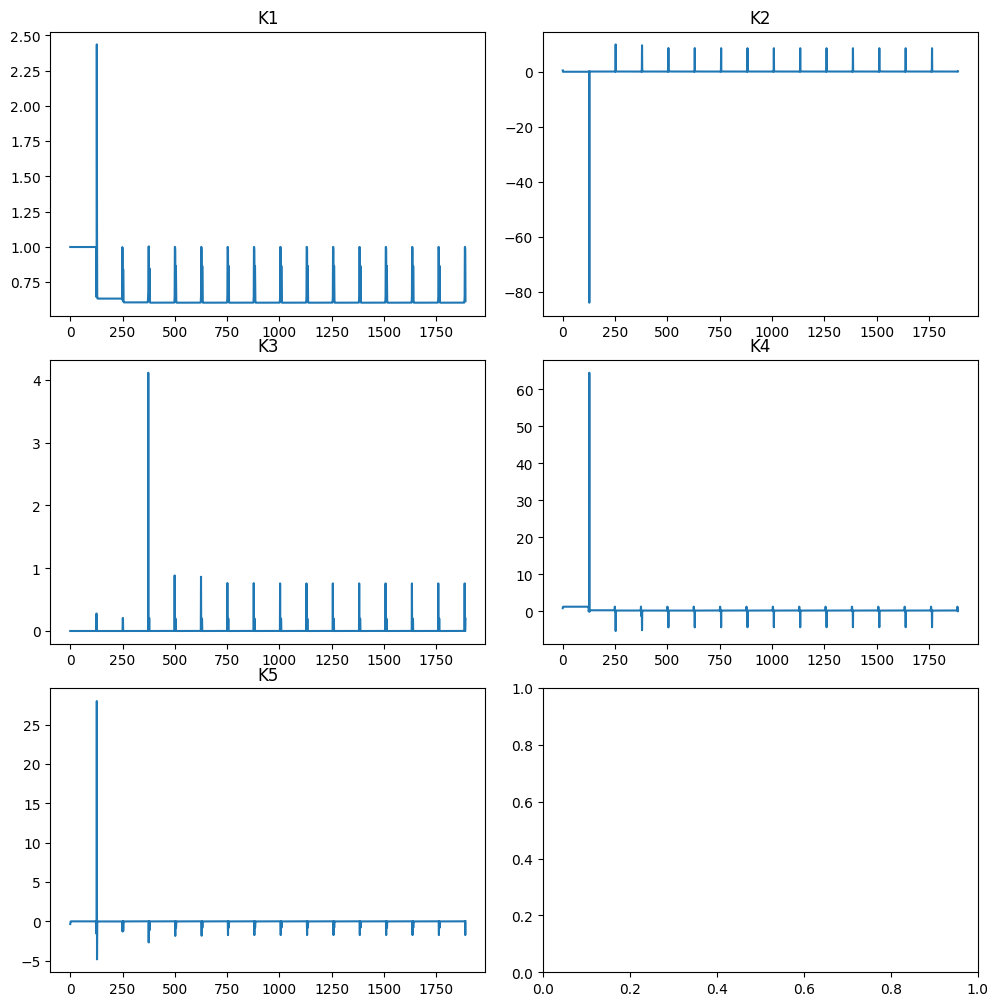

In [ ]:
# Plot K
n_rows = 15 # number of rows for the plot (max at 127)
n_columns = 126 # number of columns for the plot (max at 126)

row = np.array(range(n_rows))
row = row[:,np.newaxis]
column = np.array(range(n_columns))
column = column[np.newaxis,:]

M, N = re.shape
K = k
K = K[row,column,:]

fig, axs = plt.subplots(3, 2, figsize=(10,10))
fig.tight_layout()

axs[0,0].plot(K[:,:,0].reshape(-1))
axs[0,0].set_title("K1")
axs[0,1].plot(K[:,:,1].reshape(-1))
axs[0,1].set_title("K2")
axs[1,0].plot(K[:,:,2].reshape(-1))
axs[1,0].set_title("K3")
axs[1,1].plot(K[:,:,3].reshape(-1))
axs[1,1].set_title("K4")
axs[2,0].plot(K[:,:,4].reshape(-1))
axs[2,0].set_title("K5")

K_ss = np.zeros(5)
for i in range(5):
  unique_values, unique_indices = np.unique(np.round(K[:,:,i],4), return_counts=True)
  most_frequent_value = unique_values[np.argmax(unique_indices)]
  K_ss[i] = most_frequent_value

  print("K" + str(i+1) + ": " + str(most_frequent_value) + "\n")

Apply the calculated steady-state gain to the 512x512 noisy image.

In [ ]:
# Calculation for 512x512 image
C11 = calculate_C11(a01,a10,a11)
C12 = calculate_C12(img_n,am1m1)
s2 = calculate_s2(img_n)
s1 = calculate_s1(img_n)

re, _ = kalman_filter(2, s1, s2, img_n, C11, C12, [], [], K_ss)

Show the 512x512 reconstruction image.

SNR: 8.04
MSE: 0.16


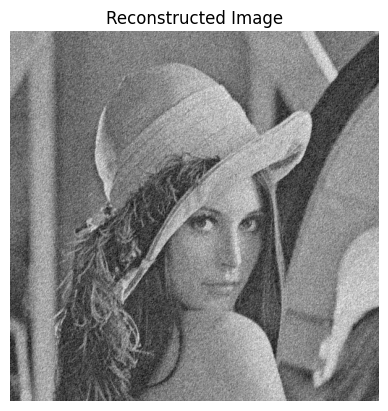

In [ ]:
# print SNR and MSE
print('SNR:', np.round(snr_dB(img_ori[1:,1:-1], re[1:,1:-1]), 2))
print('MSE:', np.round(MSE(img_ori[1:,1:-1], re[1:,1:-1]), 2))

# plot image
plt.title('Reconstructed Image')
plt.imshow(re[1:,1:-1], cmap='gray')
plt.axis('off');

Show the 512x512 original noisy image.

SNR: 5.21
MSE: 0.3


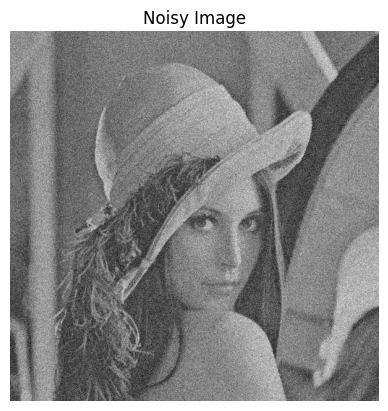

In [ ]:
# print SNR and MSE
print('SNR:', np.round(snr_dB(img_ori[1:,1:-1], img_n[1:,1:-1]), 2))
print('MSE:', np.round(MSE(img_ori[1:,1:-1], img_n[1:,1:-1]), 2))

# plot image
plt.title('Noisy Image')
plt.imshow(img_n[1:,1:-1], cmap='gray')
plt.axis('off');